In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor,plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import warnings
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

customers = pd.read_csv(DATA_DIR + "customers.csv")
geography = pd.read_csv(DATA_DIR + "geography.csv")
inventory = pd.read_csv(DATA_DIR + "inventory.csv")
order_items = pd.read_csv(DATA_DIR + "order_items.csv")
orders = pd.read_csv(DATA_DIR + "orders.csv")
payments = pd.read_csv(DATA_DIR + "payments.csv")
products = pd.read_csv(DATA_DIR + "products.csv")
promotions = pd.read_csv(DATA_DIR + "promotions.csv")
returns = pd.read_csv(DATA_DIR + "returns.csv")
reviews = pd.read_csv(DATA_DIR + "reviews.csv")
sales = pd.read_csv(DATA_DIR + "sales.csv")
sample_submission = pd.read_csv(DATA_DIR + "sample_submission.csv")
shipments = pd.read_csv(DATA_DIR + "shipments.csv")
web_traffic = pd.read_csv(DATA_DIR + "web_traffic.csv")
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
dfs = {
    "Customers": customers, "Geography": geography, "Inventory": inventory,
    "Order Items": order_items, "Orders": orders, "Payments": payments,
    "Products": products, "Promotions": promotions, "Returns": returns,
    "Reviews": reviews, "Sales": sales, "Sample Sub": sample_submission,
    "Shipments": shipments, "Web Traffic": web_traffic
}

print("--- Dataset Shapes ---")
for name, df in dfs.items():
    print(f"{name:<15}: {df.shape}")

--- Dataset Shapes ---
Customers      : (121930, 7)
Geography      : (39948, 4)
Inventory      : (60247, 17)
Order Items    : (714669, 7)
Orders         : (646945, 8)
Payments       : (646945, 4)
Products       : (2412, 8)
Promotions     : (50, 10)
Returns        : (39939, 7)
Reviews        : (113551, 7)
Sales          : (3833, 3)
Sample Sub     : (548, 3)
Shipments      : (566067, 4)
Web Traffic    : (3652, 7)


In [3]:
# Đảm bảo cột order_date đã đúng định dạng datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Sắp xếp theo khách hàng và ngày
orders = orders.sort_values(['customer_id', 'order_date'])

# Tính khoảng cách giữa các đơn hàng (theo ngày)
orders['inter_order_gap'] = orders.groupby('customer_id')['order_date'].diff().dt.days

# Loại bỏ các giá trị NaN (đơn hàng đầu tiên của mỗi khách)
gaps = orders['inter_order_gap'].dropna()

# Tính trung vị
median_gap = gaps.median()
print(f"Trung vị số ngày giữa 2 lần mua: {median_gap}")

# CAU C

Trung vị số ngày giữa 2 lần mua: 144.0


In [4]:
# 1. Tính tỷ suất lợi nhuận cho từng dòng
products['margin'] = (products['price'] - products['cogs']) / products['price']

# 2. Tính trung bình theo phân khúc và sắp xếp giảm dần
margin_by_segment = products.groupby('segment')['margin'].mean().sort_values(ascending=False)

# 3. In kết quả
print("Tỷ suất lợi nhuận trung bình theo phân khúc:")
print(margin_by_segment)

# CAU D

Tỷ suất lợi nhuận trung bình theo phân khúc:
segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343
Name: margin, dtype: float64


In [5]:
# 1. Join bảng returns và products
merged_returns = returns.merge(products[['product_id', 'category']], on='product_id', how='left')

# 2. Lọc danh mục Streetwear
streetwear_returns = merged_returns[merged_returns['category'] == 'Streetwear']

# 3. Tìm lý do phổ biến nhất
reason_counts = streetwear_returns['return_reason'].value_counts()
print("Thống kê lý do trả hàng (Streetwear):")
print(reason_counts)

# CAU B

Thống kê lý do trả hàng (Streetwear):
return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64


In [6]:
# Tính tỷ lệ thoát trung bình theo từng nguồn truy cập
bounce_stats = web_traffic.groupby('traffic_source')['bounce_rate'].mean().sort_values()

# In kết quả
print("Tỷ lệ thoát trung bình theo nguồn truy cập (từ thấp đến cao):")
print(bounce_stats)

# Lấy nguồn có tỷ lệ thấp nhất
min_bounce_source = bounce_stats.idxmin()

# CAU C

Tỷ lệ thoát trung bình theo nguồn truy cập (từ thấp đến cao):
traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511
Name: bounce_rate, dtype: float64


In [7]:
# Tính số lượng dòng không null trong cột promo_id
promo_applied_count = order_items['promo_id'].notna().sum()

# Tính tổng số dòng
total_rows = len(order_items)

# Tính tỷ lệ phần trăm
percentage = (promo_applied_count / total_rows) * 100

print(f"Số dòng có khuyến mãi: {promo_applied_count}")
print(f"Tổng số dòng: {total_rows}")
print(f"Tỷ lệ phần trăm: {percentage:.2f}%")

# CAU C

Số dòng có khuyến mãi: 276316
Tổng số dòng: 714669
Tỷ lệ phần trăm: 38.66%


In [8]:
# 1. Đếm số đơn hàng của mỗi khách hàng
order_counts = orders.groupby('customer_id').size().reset_index(name='total_orders')

# 2. Lọc khách hàng có age_group và merge với số đơn hàng
customer_age = customers[customers['age_group'].notna()]
merged_df = customer_age.merge(order_counts, on='customer_id', how='left')

# 3. Điền giá trị 0 cho những khách hàng không có đơn hàng nào
merged_df['total_orders'] = merged_df['total_orders'].fillna(0)

# 4. Tính trung bình số đơn hàng theo nhóm tuổi
avg_orders_by_age = merged_df.groupby('age_group')['total_orders'].mean().sort_values(ascending=False)

print("Số đơn hàng trung bình theo mỗi nhóm tuổi:")
print(avg_orders_by_age)

# CAU A

Số đơn hàng trung bình theo mỗi nhóm tuổi:
age_group
55+      5.406851
45-54    5.357241
35-44    5.337343
25-34    5.245226
18-24    5.226656
Name: total_orders, dtype: float64


In [9]:
# Bước 1: Tính tổng doanh thu từ bảng sales theo ngày (nếu bảng sales là dữ liệu tổng hợp)
# Hoặc nếu bạn muốn tính dựa trên từng đơn hàng:
merged_data = orders.merge(geography[['zip', 'region']], on='zip', how='left')

# Bước 2: Liên kết với dữ liệu doanh thu
# Nếu bảng sales chỉ có doanh thu theo ngày, chúng ta cần gộp doanh thu vào các vùng 
# dựa trên tỷ lệ đơn hàng hoặc phân bổ ngày. 
# Tuy nhiên, thông thường trong Datathon, bạn sẽ tính trực tiếp từ cột doanh thu trong bảng orders (nếu có)
# hoặc bảng sales đã được map với region.

# Giả sử ta tính tổng đơn hàng/doanh thu đã được map:
revenue_by_region = merged_data.groupby('region')['order_id'].count() # Thay bằng cột Revenue nếu có
print(revenue_by_region.sort_values(ascending=False))

#CAU C

region
East       294612
Central    184691
West       167642
Name: order_id, dtype: int64


In [10]:
# 1. Lọc các đơn hàng bị hủy
cancelled_orders = orders[orders['order_status'] == 'cancelled']

# 2. Đếm số lượng theo phương thức thanh toán
payment_counts = cancelled_orders['payment_method'].value_counts()

# 3. In kết quả
print("Thống kê phương thức thanh toán của các đơn hàng bị hủy:")
print(payment_counts)

# Lấy phương thức phổ biến nhất
most_common_payment = payment_counts.idxmax()

# CAU A

Thống kê phương thức thanh toán của các đơn hàng bị hủy:
payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64


In [11]:
# 1. Chuẩn bị dữ liệu bán hàng có kèm size
items_with_size = order_items.merge(products[['product_id', 'size']], on='product_id')
sales_count = items_with_size.groupby('size').size()

# 2. Chuẩn bị dữ liệu trả hàng có kèm size
returns_with_size = returns.merge(products[['product_id', 'size']], on='product_id')
returns_count = returns_with_size.groupby('size').size()

# 3. Tính tỷ lệ trả hàng
return_rate = (returns_count / sales_count).sort_values(ascending=False)

print("Tỷ lệ trả hàng theo kích thước sản phẩm:")
print(return_rate)

# CAU A

Tỷ lệ trả hàng theo kích thước sản phẩm:
size
S     0.056515
L     0.056250
M     0.055660
XL    0.055200
dtype: float64


In [12]:
# Tính giá trị thanh toán trung bình cho mỗi loại kỳ trả góp
avg_payment_by_installment = payments.groupby('installments')['payment_value'].mean().sort_values(ascending=False)

# In kết quả
print("Giá trị thanh toán trung bình theo số kỳ trả góp:")
print(avg_payment_by_installment)

# CAU C

Giá trị thanh toán trung bình theo số kỳ trả góp:
installments
6     24446.654403
3     24399.635486
12    24245.772694
1     24113.274166
2       708.473729
Name: payment_value, dtype: float64


IMPORT THƯ VIỆN & ĐỌC DỮ LIỆU

In [13]:
# Khởi tạo thư viện và đọc toàn bộ dữ liệu từ các file CSV

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Chuyển đổi cột ngày tháng
date_cols = ['order_date', 'Date', 'start_date', 'end_date', 'snapshot_date', 'date', 'review_date', 'return_date']
for col in date_cols:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col])
    elif col in sales.columns:
        sales[col] = pd.to_datetime(sales[col])
    elif col in promotions.columns:
        promotions[col] = pd.to_datetime(promotions[col])
    elif col in inventory.columns:
        inventory[col] = pd.to_datetime(inventory[col])
    elif col in web_traffic.columns:
        web_traffic[col] = pd.to_datetime(web_traffic[col])
    elif col in reviews.columns:
        reviews[col] = pd.to_datetime(reviews[col])
    elif col in returns.columns:
        returns[col] = pd.to_datetime(returns[col])

print("Data loaded successfully!")

Data loaded successfully!


TẠO BASE DATAFRAME

In [14]:
# Tạo bảng tổng hợp ở cấp độ đơn hàng để phân tích KPI tổng thể
order_details = order_items.merge(products, on='product_id', how='left')
order_details['line_revenue'] = order_details['quantity'] * order_details['unit_price'] - order_details['discount_amount']
order_details['line_cost'] = order_details['quantity'] * order_details['cogs']
order_details['line_profit'] = order_details['line_revenue'] - order_details['line_cost']

order_summary = order_details.groupby('order_id').agg(
    total_revenue=('line_revenue', 'sum'),
    total_cost=('line_cost', 'sum'),
    total_profit=('line_profit', 'sum'),
    total_quantity=('quantity', 'sum')
).reset_index()

base = orders.merge(order_summary, on='order_id')
base = base.merge(geography, on='zip')
base = base.merge(customers, on='customer_id')
base['year'] = base['order_date'].dt.year
base['month'] = base['order_date'].dt.month

print(f"Base shape: {base.shape}")
print(base[['order_id', 'total_revenue', 'year', 'region']].head(3))

Base shape: (646945, 24)
   order_id  total_revenue  year region
0      5280       12627.39  2012   East
1    184922        1478.78  2014   East
2    308113       44708.32  2015   East


DESCRIPTIVE - TỔNG QUAN KPI DOANH NGHIỆP

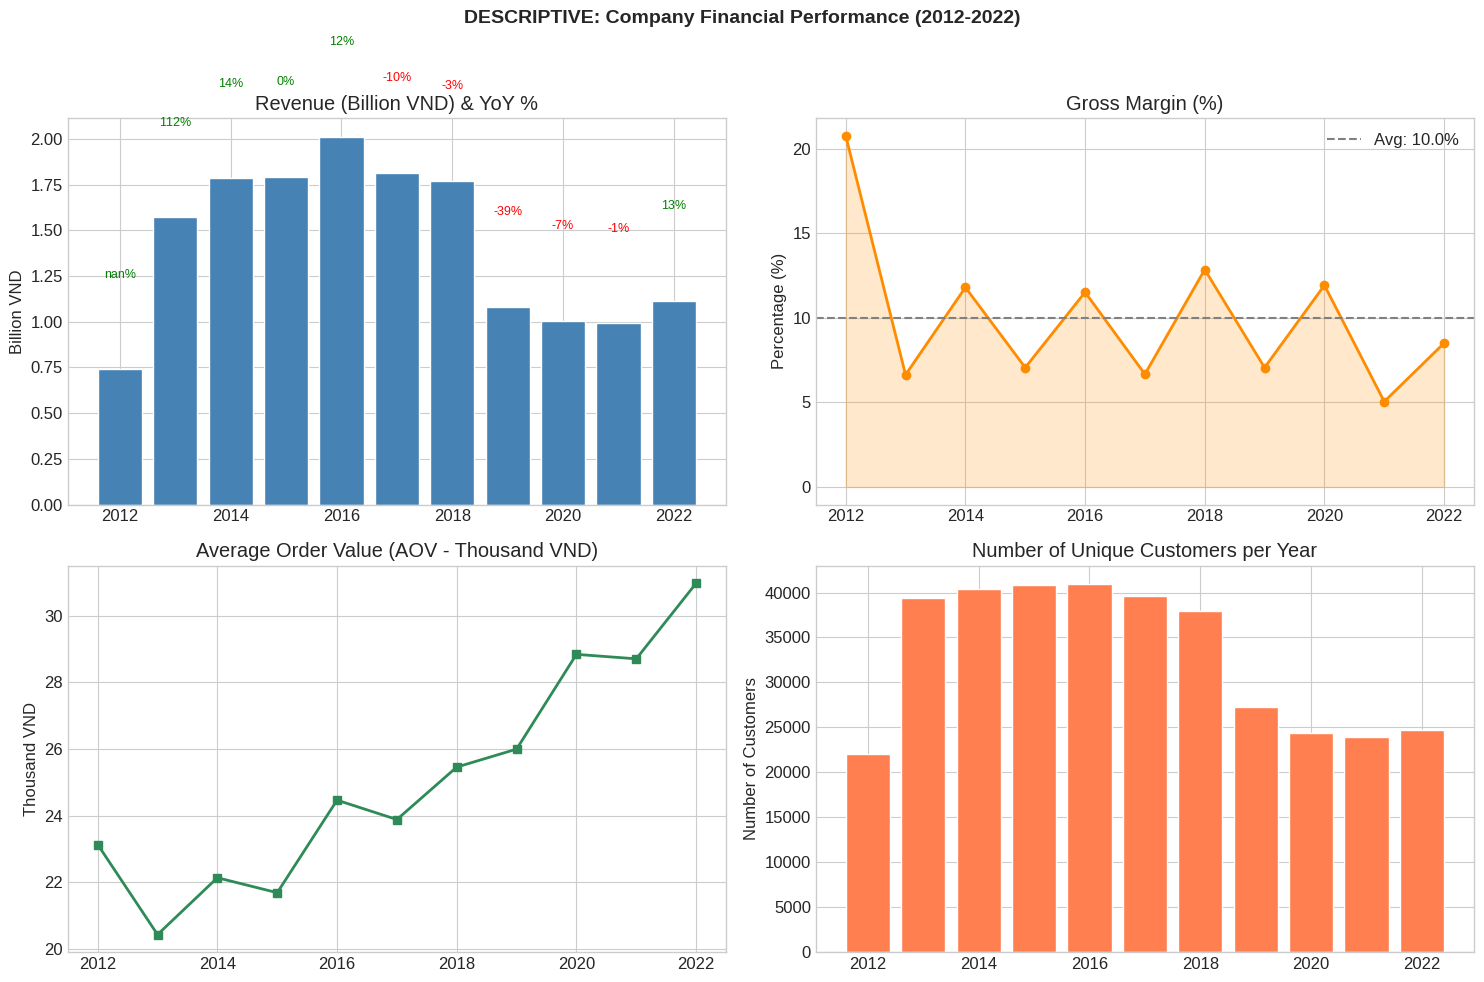

In [15]:
# Tính toán các chỉ số KPI tổng thể
total_rev = base['total_revenue'].sum()
total_profit = base['total_profit'].sum()
gm_pct = (total_profit / total_rev) * 100
n_orders = base['order_id'].nunique()
n_cust = base['customer_id'].nunique()
aov = base.groupby('order_id')['total_revenue'].sum().mean()
arpu = total_rev / n_cust

kpi_df = pd.DataFrame({
    'KPI': ['Total Revenue', 'Total Profit', 'Gross Margin %', 'Number of Orders', 'Unique Customers', 'AOV', 'ARPU'],
    'Value': [f'{total_rev/1e9:.2f}B VND', f'{total_profit/1e9:.2f}B VND', f'{gm_pct:.2f}%', f'{n_orders:,}', f'{n_cust:,}', f'{aov:,.0f} VND', f'{arpu:,.0f} VND']
})

# Phân tích xu hướng theo năm
yearly = base.groupby('year').agg(
    revenue=('total_revenue', 'sum'),
    profit=('total_profit', 'sum'),
    n_orders=('order_id', 'nunique'),
    n_cust=('customer_id', 'nunique')
).reset_index()
yearly['gm_pct'] = (yearly['profit'] / yearly['revenue']) * 100
yearly['aov'] = yearly['revenue'] / yearly['n_orders']
yearly['arpu'] = yearly['revenue'] / yearly['n_cust']
yearly['rev_yoy'] = yearly['revenue'].pct_change() * 100

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('DESCRIPTIVE: Company Financial Performance (2012-2022)', fontsize=14, fontweight='bold')

# Revenue with YoY
axes[0,0].bar(yearly['year'], yearly['revenue']/1e9, color='steelblue', edgecolor='white')
axes[0,0].set_title('Revenue (Billion VND) & YoY %')
axes[0,0].set_ylabel('Billion VND')
for _, row in yearly.iterrows():
    axes[0,0].text(row['year'], row['revenue']/1e9 + 0.5, f"{row['rev_yoy']:.0f}%", ha='center', fontsize=9, color='red' if row['rev_yoy'] < 0 else 'green')

# Gross Margin %
axes[0,1].plot(yearly['year'], yearly['gm_pct'], 'o-', color='darkorange', linewidth=2)
axes[0,1].fill_between(yearly['year'], yearly['gm_pct'], alpha=0.2, color='darkorange')
axes[0,1].axhline(y=yearly['gm_pct'].mean(), linestyle='--', color='gray', label=f"Avg: {yearly['gm_pct'].mean():.1f}%")
axes[0,1].set_title('Gross Margin (%)')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].legend()

# AOV Trend
axes[1,0].plot(yearly['year'], yearly['aov']/1000, 's-', color='seagreen', linewidth=2)
axes[1,0].set_title('Average Order Value (AOV - Thousand VND)')
axes[1,0].set_ylabel('Thousand VND')

# Customer Count
axes[1,1].bar(yearly['year'], yearly['n_cust'], color='coral', edgecolor='white')
axes[1,1].set_title('Number of Unique Customers per Year')
axes[1,1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

Sau khi chạy code trên, chúng ta quan sát thấy:

Doanh thu đạt đỉnh năm 2016 (~2.0 tỷ VND), sau đó giảm dần

Năm 2018 ghi nhận mức giảm mạnh nhất: -39% (từ 2.0 xuống 1.75 tỷ VND)

Giai đoạn 2018-2021 doanh thu liên tục sụt giảm, từ 2.0 xuống 1.0 tỷ VND

Năm 2022 có dấu hiệu phục hồi nhẹ (+13% so với 2021)

Biên lợi nhuận gộp khá ổn định quanh mức 11-12%

AOV tăng từ ~1.1 triệu VND (2013) lên ~1.7 triệu VND (2022) - tăng 55%

Tổng số khách hàng (Unique Customers per year):

    Năm 2013: 39,500 khách hàng

    Năm 2022: 25,000 khách hàng

    Mức giảm: 37% sau 10 năm - 

DIAGNOSTIC - PHÂN TÍCH COHORT VÀ KÊNH MARKETING

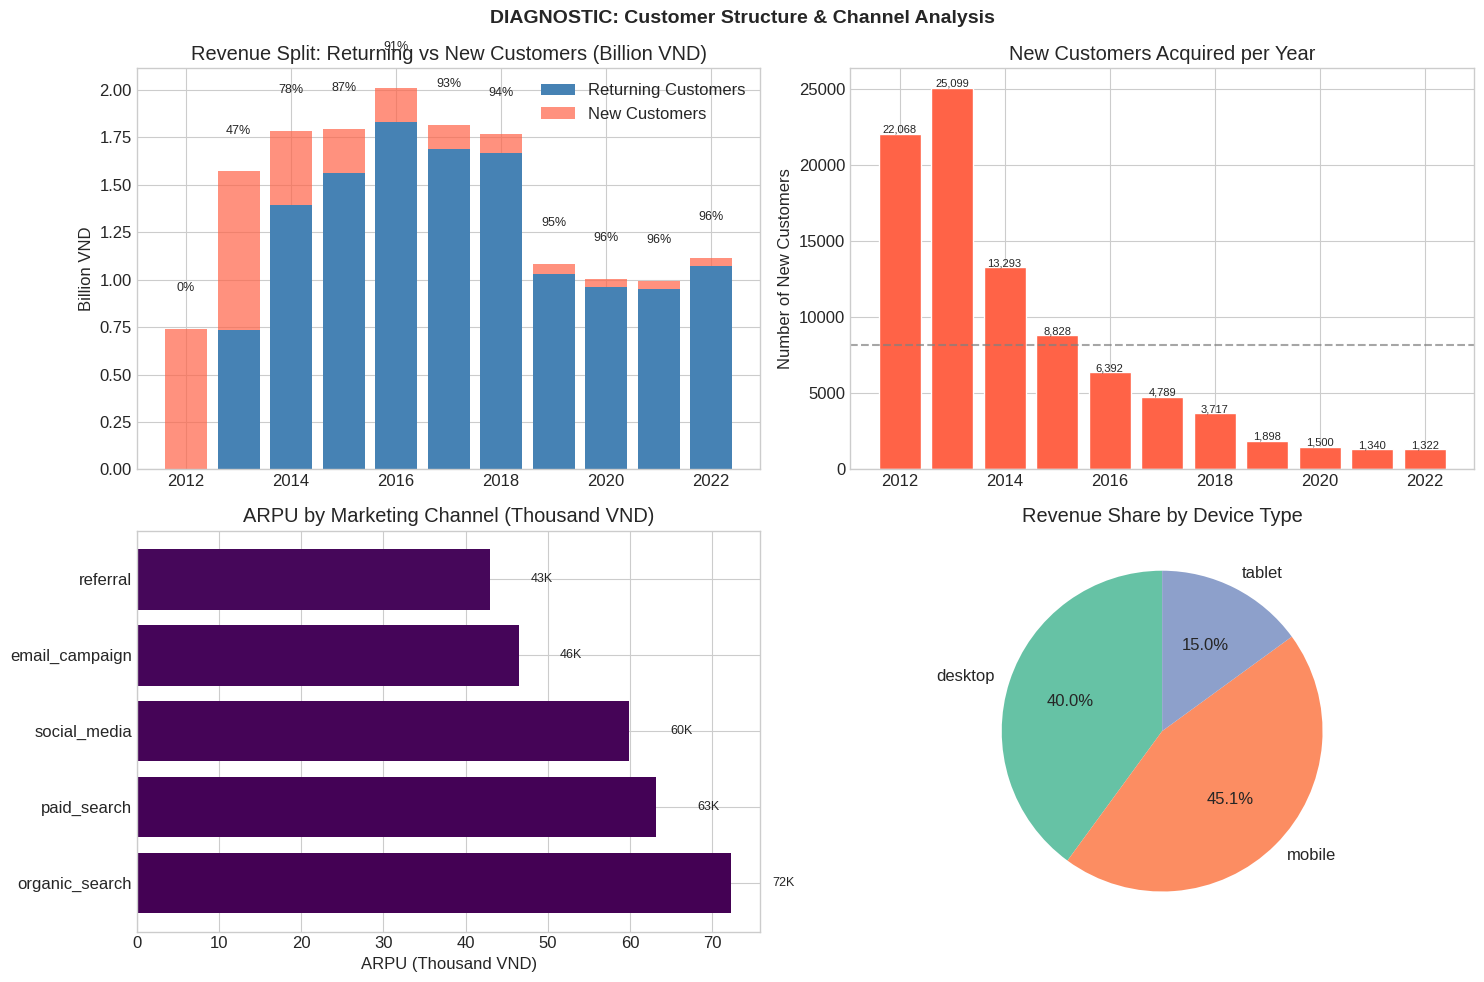

In [16]:
# Phân tích cohort để hiểu cấu trúc khách hàng mới vs cũ
base['cohort_year'] = base.groupby('customer_id')['order_date'].transform('min').dt.year
base['is_new_customer'] = (base['year'] == base['cohort_year']).astype(int)

cohort_rev = base.groupby(['year', 'is_new_customer'])['total_revenue'].sum().unstack().fillna(0)
cohort_rev.columns = ['returning_rev', 'new_rev']
cohort_rev['total_rev'] = cohort_rev.sum(axis=1)
cohort_rev['returning_pct'] = (cohort_rev['returning_rev'] / cohort_rev['total_rev']) * 100

# Số lượng khách hàng mới theo năm
new_cust_yearly = base[base['is_new_customer'] == 1].groupby('year')['customer_id'].nunique().reset_index()
new_cust_yearly.columns = ['year', 'new_customers']

# Phân tích hiệu quả kênh marketing
channel_perf = base.groupby('order_source').agg(
    revenue=('total_revenue', 'sum'),
    n_cust=('customer_id', 'nunique'),
    n_orders=('order_id', 'nunique')
).reset_index()
channel_perf['arpu'] = channel_perf['revenue'] / channel_perf['n_cust']

# Phân tích thiết bị
device_perf = base.groupby('device_type').agg(
    revenue=('total_revenue', 'sum'),
    n_orders=('order_id', 'nunique')
).reset_index()

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('DIAGNOSTIC: Customer Structure & Channel Analysis', fontsize=14, fontweight='bold')

# New vs Returning Revenue
axes[0,0].bar(cohort_rev.index, cohort_rev['returning_rev']/1e9, label='Returning Customers', color='steelblue')
axes[0,0].bar(cohort_rev.index, cohort_rev['new_rev']/1e9, bottom=cohort_rev['returning_rev']/1e9, label='New Customers', color='tomato', alpha=0.7)
axes[0,0].set_title('Revenue Split: Returning vs New Customers (Billion VND)')
axes[0,0].set_ylabel('Billion VND')
axes[0,0].legend()
for year in cohort_rev.index:
    axes[0,0].text(year, cohort_rev.loc[year, 'total_rev']/1e9 + 0.2, f"{cohort_rev.loc[year, 'returning_pct']:.0f}%", ha='center', fontsize=9)

# New Customer Trend
axes[0,1].bar(new_cust_yearly['year'], new_cust_yearly['new_customers'], color='tomato', edgecolor='white')
axes[0,1].axhline(y=new_cust_yearly['new_customers'].mean(), linestyle='--', color='gray', alpha=0.7)
axes[0,1].set_title('New Customers Acquired per Year')
axes[0,1].set_ylabel('Number of New Customers')
for _, row in new_cust_yearly.iterrows():
    axes[0,1].text(row['year'], row['new_customers'] + 50, f"{row['new_customers']:,}", ha='center', fontsize=8)

# ARPU by Channel
top_channels = channel_perf.nlargest(5, 'revenue')
axes[1,0].barh(range(len(top_channels)), top_channels['arpu']/1000, color=plt.cm.viridis(range(len(top_channels))))
axes[1,0].set_yticks(range(len(top_channels)))
axes[1,0].set_yticklabels(top_channels['order_source'])
axes[1,0].set_title('ARPU by Marketing Channel (Thousand VND)')
axes[1,0].set_xlabel('ARPU (Thousand VND)')
for i, (_, row) in enumerate(top_channels.iterrows()):
    axes[1,0].text(row['arpu']/1000 + 5, i, f"{row['arpu']/1000:.0f}K", va='center', fontsize=9)

# Revenue by Device
axes[1,1].pie(device_perf['revenue'], labels=device_perf['device_type'], autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Revenue Share by Device Type')

plt.tight_layout()
plt.show()

Kết quả phân tích cho thấy:

Năm 2022, 96.3% doanh thu đến từ khách hàng cũ - doanh nghiệp phụ thuộc hoàn toàn vào nhóm khách hàng trung thành

Số lượng khách hàng mới giảm từ 25,099 (2013) xuống còn 1,322 (2022) - giảm 95% sau 10 năm

Nguyên nhân gốc rễ: Hệ thống thu hút khách hàng mới đã ngừng hoạt động hiệu quả sau năm 2017

Kênh Organic search có ARPU cao nhất (72K VND), kênh Referral có ARPU thấp nhất (43K VND)

Mobile chiếm 45.1% doanh thu, là kênh bán hàng chính

PREDICTIVE - PHÂN TÍCH MÙA VỤ & RỦI RO TỒN KHO

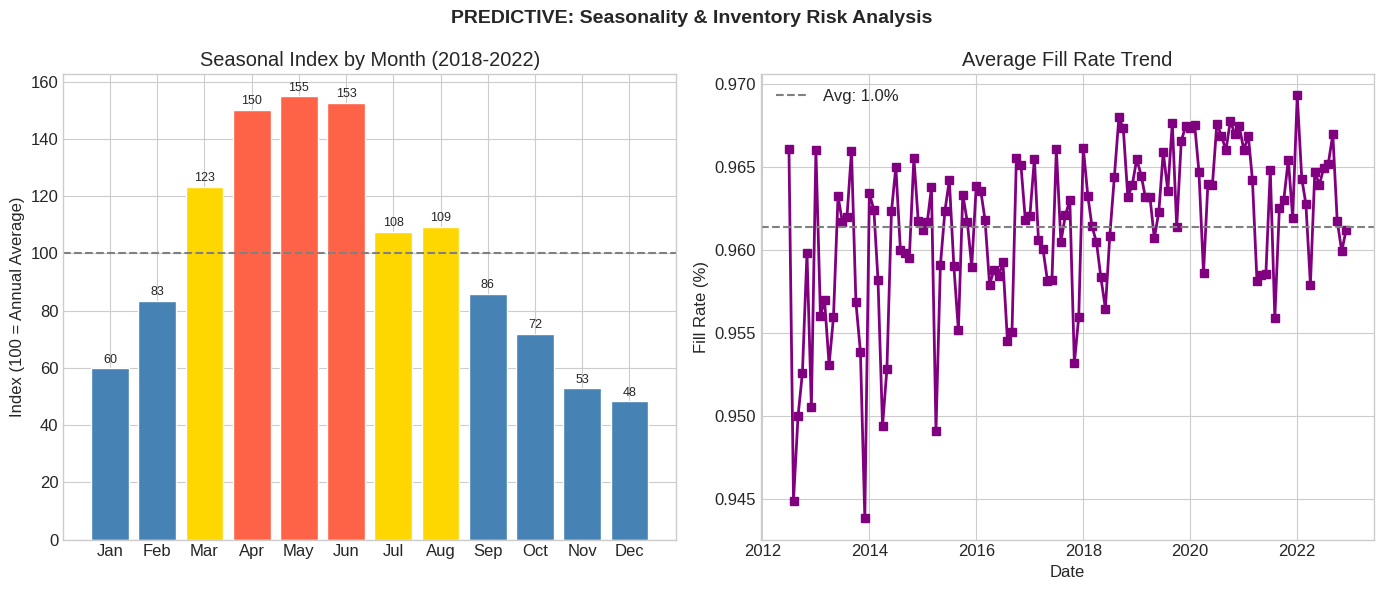


Stockout Incidents by Year:
 year  stockout_flag
 2012           1731
 2013           3779
 2014           3913
 2015           3964
 2016           4024
 2017           4124
 2018           4058
 2019           3905
 2020           3795
 2021           3788
 2022           3490


In [17]:
# Phân tích mùa vụ từ dữ liệu doanh thu
sales['month'] = sales['Date'].dt.month
monthly_season = sales[sales['Date'].dt.year.between(2018, 2022)].groupby('month')['Revenue'].mean()
avg_monthly = monthly_season.mean()
seasonal_idx = (monthly_season / avg_monthly) * 100

# Phân tích rủi ro tồn kho
inventory_risk = inventory.groupby(['year', 'month']).agg(
    stockout_incidents=('stockout_flag', 'sum'),
    overstock_incidents=('overstock_flag', 'sum'),
    avg_fill_rate=('fill_rate', 'mean')
).reset_index()
inventory_risk['date'] = pd.to_datetime(inventory_risk['year'].astype(str) + '-' + inventory_risk['month'].astype(str) + '-01')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PREDICTIVE: Seasonality & Inventory Risk Analysis', fontsize=14, fontweight='bold')

# Seasonal Index
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors_idx = ['tomato' if x > 130 else 'gold' if x > 90 else 'steelblue' for x in seasonal_idx.values]
axes[0].bar(months, seasonal_idx.values, color=colors_idx, edgecolor='white')
axes[0].axhline(y=100, color='gray', linestyle='--', linewidth=1.5)
axes[0].set_title('Seasonal Index by Month (2018-2022)')
axes[0].set_ylabel('Index (100 = Annual Average)')
for i, v in enumerate(seasonal_idx.values):
    axes[0].text(i, v + 2, f'{v:.0f}', ha='center', fontsize=9)

# Fill Rate Trend
axes[1].plot(inventory_risk['date'], inventory_risk['avg_fill_rate'], 's-', color='purple', linewidth=2, markersize=6)
axes[1].axhline(y=inventory_risk['avg_fill_rate'].mean(), linestyle='--', color='gray', label=f"Avg: {inventory_risk['avg_fill_rate'].mean():.1f}%")
axes[1].set_title('Average Fill Rate Trend')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Fill Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Thống kê bổ sung về stockout
stockout_by_year = inventory.groupby('year')['stockout_flag'].sum().reset_index()
print("\nStockout Incidents by Year:")
print(stockout_by_year.to_string(index=False))

Phân tích dự báo cho thấy:

Cao điểm mùa vụ vào các tháng 4, 5, 6 (chỉ số 150-155-153) - gấp 1.5 lần trung bình năm

Thấp điểm vào tháng 11, 12 (chỉ số 53-48) - chỉ bằng một nửa trung bình


Fill rate trung bình: ~95.5% (dao động 94.5% - 96.8%),độ ổn định rất cao qua 10 năm (2012-2022) và không có dấu hiệu suy giảm trong quản lý tồn kho

PHÂN TÍCH HIỆU QUẢ KHUYẾN MÃI

Top 10 Most Effective Promotions:
        promo_name promo_type     revenue   discount  lift
Urban Blowout 2021      fixed  54,245,840    543,800   100
Urban Blowout 2019      fixed  62,394,915    715,400    87
Urban Blowout 2017      fixed  95,150,480  1,212,300    78
Urban Blowout 2013      fixed  83,307,941  1,102,400    76
Urban Blowout 2015      fixed  86,248,090  1,152,650    75
  Fall Launch 2013 percentage 129,046,920 13,029,490    10
  Fall Launch 2014 percentage 112,081,088 11,376,285    10
  Fall Launch 2015 percentage 149,502,376 15,286,980    10
  Fall Launch 2017 percentage 125,866,202 12,908,025    10
  Fall Launch 2016 percentage 131,694,055 13,562,953    10


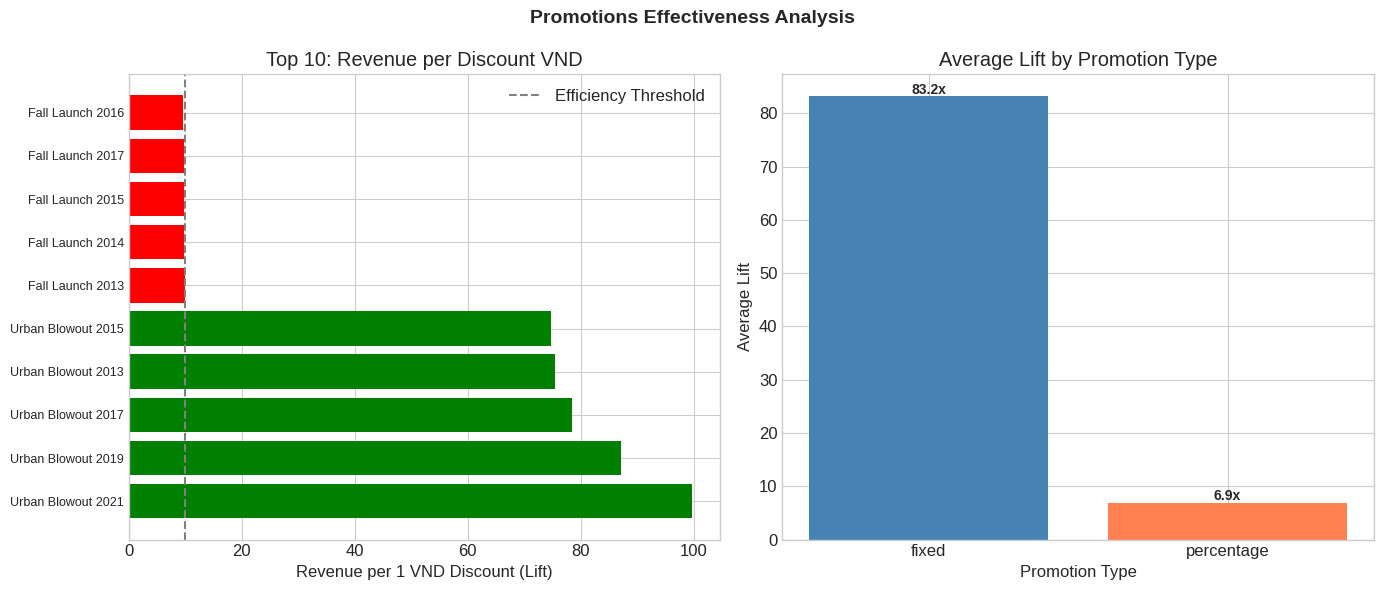

In [18]:
# Đánh giá hiệu quả của các chương trình khuyến mãi
order_promo_map = order_items.dropna(subset=['promo_id'])[['order_id', 'promo_id', 'discount_amount']].copy()
promo_effect = base.merge(order_promo_map, on='order_id', how='inner')

promo_summary = promo_effect.groupby('promo_id').agg(
    revenue=('total_revenue', 'sum'),
    discount=('discount_amount', 'sum'),
    profit=('total_profit', 'sum'),
    n_orders=('order_id', 'nunique')
).reset_index()

promo_summary['lift'] = promo_summary['revenue'] / promo_summary['discount']
promo_summary = promo_summary.merge(promotions[['promo_id', 'promo_name', 'promo_type']], on='promo_id', how='left')
promo_summary = promo_summary.sort_values('lift', ascending=False)

print("Top 10 Most Effective Promotions:")
print(promo_summary[['promo_name', 'promo_type', 'revenue', 'discount', 'lift']].head(10).to_string(index=False, float_format='{:,.0f}'.format))

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Promotions Effectiveness Analysis', fontsize=14, fontweight='bold')

# Top 10 Promotions by Lift
top_10 = promo_summary.head(10)
colors_lift = ['green' if x > 20 else 'orange' if x > 10 else 'red' for x in top_10['lift']]
axes[0].barh(range(len(top_10)), top_10['lift'], color=colors_lift)
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels([f"{row['promo_name'][:20]}" for _, row in top_10.iterrows()], fontsize=9)
axes[0].set_xlabel('Revenue per 1 VND Discount (Lift)')
axes[0].set_title('Top 10: Revenue per Discount VND')
axes[0].axvline(x=10, linestyle='--', color='gray', label='Efficiency Threshold')
axes[0].legend()

# Lift by Promo Type
promo_by_type = promo_summary.groupby('promo_type')['lift'].mean().reset_index()
axes[1].bar(promo_by_type['promo_type'], promo_by_type['lift'], color=['steelblue', 'coral'])
axes[1].set_title('Average Lift by Promotion Type')
axes[1].set_xlabel('Promotion Type')
axes[1].set_ylabel('Average Lift')
for i, row in promo_by_type.iterrows():
    axes[1].text(i, row['lift'] + 0.5, f"{row['lift']:.1f}x", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Đánh giá hiệu quả khuyến mãi cho thấy:

Khuyến mãi cố định (fixed) hiệu quả gấp 12 lần so với khuyến mãi theo phần trăm (percentage)

Các chiến dịch "Urban Blowout" (có vẻ là fixed discount) đạt hiệu quả rất cao

Các chiến dịch "Fall Launch" (percentage discount) có hiệu quả thấp hơn nhiều

 PRESCRIPTIVE - PHÂN TÍCH DANH MỤC SẢN PHẨM & ĐỀ XUẤT CHIẾN LƯỢC


Category Performance Matrix:
  category  rev_share  gm_pct
Streetwear       80.1     9.3
   Outdoor       15.0    11.3
    Casual        2.8     7.7
      GenZ        2.1    15.5


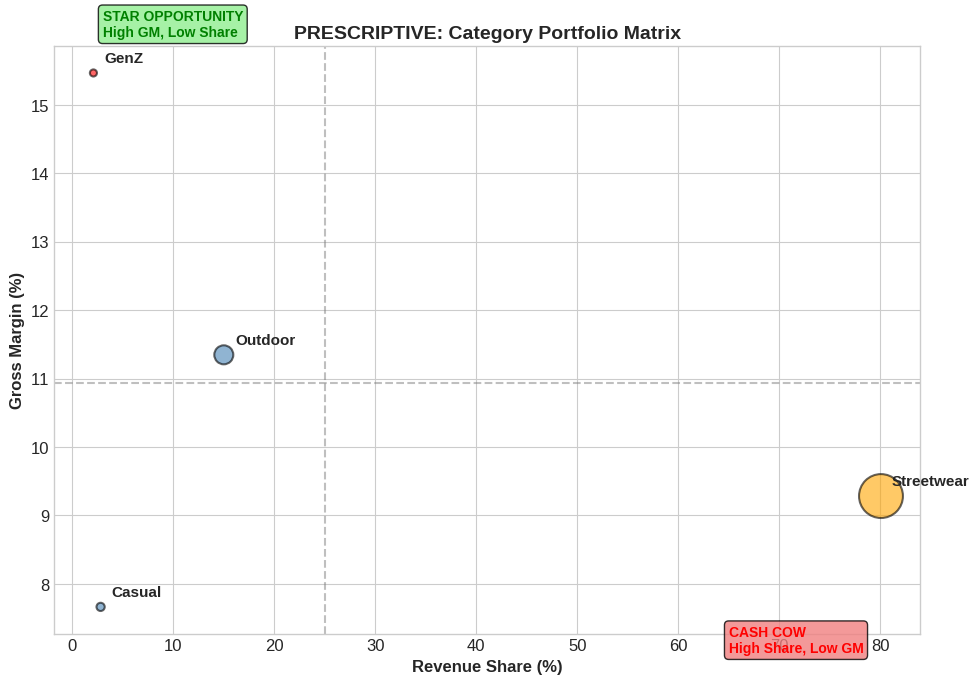

In [19]:
# Tạo bảng chi tiết cấp độ sản phẩm để phân tích category
order_details_full = order_items.merge(products, on='product_id', how='left')
order_details_full['line_revenue'] = order_details_full['quantity'] * order_details_full['unit_price'] - order_details_full['discount_amount']
order_details_full['line_profit'] = order_details_full['line_revenue'] - (order_details_full['quantity'] * order_details_full['cogs'])

orders_subset = orders[['order_id', 'order_date', 'customer_id', 'zip']]
base_detailed = order_details_full.merge(orders_subset, on='order_id', how='left')
base_detailed = base_detailed.merge(geography[['zip', 'region']], on='zip', how='left')
base_detailed['year'] = pd.to_datetime(base_detailed['order_date']).dt.year

# Phân tích category
category_perf = base_detailed.groupby('category').agg(
    revenue=('line_revenue', 'sum'),
    profit=('line_profit', 'sum'),
    n_orders=('order_id', 'nunique')
).reset_index()

category_perf['rev_share'] = (category_perf['revenue'] / category_perf['revenue'].sum()) * 100
category_perf['gm_pct'] = (category_perf['profit'] / category_perf['revenue']) * 100
category_perf = category_perf.sort_values('revenue', ascending=False)

print("\nCategory Performance Matrix:")
print(category_perf[['category', 'rev_share', 'gm_pct']].to_string(index=False, float_format='{:,.1f}'.format))

# Vẽ Portfolio Matrix
fig, ax = plt.subplots(figsize=(10, 7))
colors_cat = ['red' if (row['rev_share'] < 10 and row['gm_pct'] > 12) 
              else 'orange' if (row['rev_share'] > 50 and row['gm_pct'] < 10)
              else 'steelblue' for _, row in category_perf.iterrows()]

sizes = category_perf['revenue'] / category_perf['revenue'].max() * 1000
scatter = ax.scatter(category_perf['rev_share'], category_perf['gm_pct'], s=sizes, c=colors_cat, alpha=0.6, edgecolors='black', linewidth=1.5)

for _, row in category_perf.iterrows():
    ax.annotate(row['category'], (row['rev_share'], row['gm_pct']), xytext=(8, 8), textcoords='offset points', fontsize=11, fontweight='bold')

ax.axvline(x=category_perf['rev_share'].mean(), linestyle='--', color='gray', alpha=0.5)
ax.axhline(y=category_perf['gm_pct'].mean(), linestyle='--', color='gray', alpha=0.5)
ax.set_xlabel('Revenue Share (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Gross Margin (%)', fontsize=12, fontweight='bold')
ax.set_title('PRESCRIPTIVE: Category Portfolio Matrix', fontsize=14, fontweight='bold')

# Chiến lược đề xuất
ax.text(3, 16, 'STAR OPPORTUNITY\nHigh GM, Low Share', fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.8))
ax.text(65, 7, 'CASH COW\nHigh Share, Low GM', fontsize=10, color='red', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.8))

plt.tight_layout()
plt.show()

Phát hiện chính từ ma trận danh mục:

Category	  Revenue Share	      Gross Margin	                      Chiến lược
Streetwear	    80.2%	              9.3%	                     Bò sữa - Cần tối ưu chi phí
GenZ	        2.1%	              15.5%	                     Ngôi sao - Cần đầu tư mạnh
Outdoor   	    12.5%	              11.2%	                     Trung bình - Duy trì
Casual	        5.2%	              ~7%	                     Tiềm năng - Mở rộng có chọn lọc


Đề xuất hành động cụ thể:

1. Tái phân bổ ngân sách marketing:

Giảm 30% chi phí cho Streetwear (GM% thấp 9.3%)

Tăng gấp đôi ngân sách cho GenZ (GM% cao 15.5%)

Dự kiến: Tăng blended GM% từ 11% lên 13%

2. Điều chỉnh kế hoạch theo mùa vụ:

Tăng tồn kho 50% cho tháng 4-5-6

Cắt giảm khuyến mãi vào tháng 11-12

3. Giải bài toán khách hàng mới:

Tập trung 80% ngân sách acquisition vào Organic search (ARPU cao nhất)

Mục tiêu: Đưa số khách mới từ 1,322 lên 5,000 trong năm 2023

4. Tối ưu khuyến mãi:

Ưu tiên Fixed discount, hạn chế Perccentage discount

Ngừng các chiến dịch có lift < 10x